In [1]:
from PIL import Image, ImageDraw
from pathlib import Path

import json
import matplotlib.pyplot as plt
import random
import time
import torch
import torch.backends.cudnn as cudnn
import torch.optim
import torch.utils.data
import torchvision
import xml.etree.ElementTree as ET

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

device

device(type='mps')

In [2]:
PROJECT_DIR = Path.cwd()
TUTORIAL_DIR = PROJECT_DIR / "a-PyTorch-Tutorial-to-Object-Detection"
BCCD_DIR = PROJECT_DIR / "BCCD_Dataset" / "BCCD"
DATA_LISTS_DIR = PROJECT_DIR / "bccd_ssd_data"
CHECKPOINT_PATH = PROJECT_DIR / "ssd300_bccd_best.pth.tar"

assert TUTORIAL_DIR.exists(), f"Не найдена папка tutorial: {TUTORIAL_DIR}"
assert BCCD_DIR.exists(), f"Не найдена папка BCCD: {BCCD_DIR}"

import sys

if str(TUTORIAL_DIR) not in sys.path:
    sys.path.insert(0, str(TUTORIAL_DIR))

import utils as ssd_utils
from datasets import PascalVOCDataset

ssd_utils.device = device

In [3]:
bccd_labels = ("rbc", "wbc", "platelets")
label_map = {k: v + 1 for v, k in enumerate(bccd_labels)}
label_map["background"] = 0
rev_label_map = {v: k for k, v in label_map.items()}

ssd_utils.label_map.clear()
ssd_utils.label_map.update(label_map)

ssd_utils.rev_label_map.clear()
ssd_utils.rev_label_map.update(rev_label_map)

ssd_utils.label_color_map.clear()
for i, cls_name in enumerate(ssd_utils.label_map.keys()):
    ssd_utils.label_color_map[cls_name] = ssd_utils.distinct_colors[i % len(ssd_utils.distinct_colors)]

print("label_map:", ssd_utils.label_map)

label_map: {'rbc': 1, 'wbc': 2, 'platelets': 3, 'background': 0}


In [4]:
def parse_bccd_annotation(annotation_path: Path):
    tree = ET.parse(annotation_path)
    root = tree.getroot()

    boxes, labels, difficulties = [], [], []

    for obj in root.iter("object"):
        label = obj.find("name").text.lower().strip()
        if label not in ssd_utils.label_map:
            continue

        bbox = obj.find("bndbox")
        xmin = int(float(bbox.find("xmin").text)) - 1
        ymin = int(float(bbox.find("ymin").text)) - 1
        xmax = int(float(bbox.find("xmax").text)) - 1
        ymax = int(float(bbox.find("ymax").text)) - 1

        difficult_tag = obj.find("difficult")
        difficult = int(difficult_tag.text) if difficult_tag is not None else 0

        boxes.append([xmin, ymin, xmax, ymax])
        labels.append(ssd_utils.label_map[label])
        difficulties.append(difficult)

    return {"boxes": boxes, "labels": labels, "difficulties": difficulties}


def create_bccd_data_lists(bccd_root: Path, output_folder: Path, train_split_name: str = "trainval",
                           test_split_name: str = "test"):
    output_folder.mkdir(parents=True, exist_ok=True)

    image_sets_dir = bccd_root / "ImageSets" / "Main"
    ann_dir = bccd_root / "Annotations"
    img_dir = bccd_root / "JPEGImages"

    def read_ids(file_path: Path):
        with file_path.open("r", encoding="utf-8") as f:
            return [line.strip() for line in f.readlines() if line.strip()]

    train_ids = read_ids(image_sets_dir / f"{train_split_name}.txt")
    test_ids = read_ids(image_sets_dir / f"{test_split_name}.txt")

    train_images, train_objects = [], []
    for image_id in train_ids:
        ann = parse_bccd_annotation(ann_dir / f"{image_id}.xml")
        if len(ann["boxes"]) == 0:
            continue
        train_images.append(str((img_dir / f"{image_id}.jpg").resolve()))
        train_objects.append(ann)

    test_images, test_objects = [], []
    for image_id in test_ids:
        ann = parse_bccd_annotation(ann_dir / f"{image_id}.xml")
        if len(ann["boxes"]) == 0:
            continue
        test_images.append(str((img_dir / f"{image_id}.jpg").resolve()))
        test_objects.append(ann)

    with (output_folder / "TRAIN_images.json").open("w", encoding="utf-8") as f:
        json.dump(train_images, f)
    with (output_folder / "TRAIN_objects.json").open("w", encoding="utf-8") as f:
        json.dump(train_objects, f)
    with (output_folder / "TEST_images.json").open("w", encoding="utf-8") as f:
        json.dump(test_images, f)
    with (output_folder / "TEST_objects.json").open("w", encoding="utf-8") as f:
        json.dump(test_objects, f)
    with (output_folder / "label_map.json").open("w", encoding="utf-8") as f:
        json.dump(ssd_utils.label_map, f)

    print(f"TRAIN images: {len(train_images)}")
    print(f"TEST images: {len(test_images)}")
    print(f"Saved JSON files to: {output_folder.resolve()}")


create_bccd_data_lists(BCCD_DIR, DATA_LISTS_DIR)

TRAIN images: 292
TEST images: 72
Saved JSON files to: /Users/andreivasilev/Projects/Нетология/Для GitHub/014 Домашнее задание Компьютерное зрение/bccd_ssd_data


In [5]:
keep_difficult = True
batch_size = 8
workers = 2

train_dataset = PascalVOCDataset(
    data_folder=str(DATA_LISTS_DIR),
    split="TRAIN",
    keep_difficult=keep_difficult,
)

test_dataset = PascalVOCDataset(
    data_folder=str(DATA_LISTS_DIR),
    split="TEST",
    keep_difficult=keep_difficult,
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=train_dataset.collate_fn,
    num_workers=workers,
    pin_memory=torch.cuda.is_available(),
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=test_dataset.collate_fn,
    num_workers=workers,
    pin_memory=torch.cuda.is_available(),
)

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))

Train size: 292
Test size: 72


In [6]:
images, boxes, labels, difficulties = next(iter(train_loader))
print("images:", images.shape)
print("boxes in first image:", boxes[0].shape)
print("labels in first image:", labels[0][:10])

images: torch.Size([8, 3, 300, 300])
boxes in first image: torch.Size([12, 4])
labels in first image: tensor([1, 1, 1, 1, 1, 1, 1, 1, 3, 3])


In [7]:
import model as ssd_model

ssd_model.device = device


def safe_load_pretrained_layers(self):
    state_dict = self.state_dict()
    param_names = list(state_dict.keys())

    try:
        weights = torchvision.models.VGG16_Weights.IMAGENET1K_V1
        pretrained_state_dict = torchvision.models.vgg16(weights=weights).state_dict()
        pretrained_param_names = list(pretrained_state_dict.keys())

        for i, param in enumerate(param_names[:-4]):
            state_dict[param] = pretrained_state_dict[pretrained_param_names[i]]

        conv_fc6_weight = pretrained_state_dict["classifier.0.weight"].view(4096, 512, 7, 7)
        conv_fc6_bias = pretrained_state_dict["classifier.0.bias"]
        state_dict["conv6.weight"] = ssd_utils.decimate(conv_fc6_weight, m=[4, None, 3, 3])
        state_dict["conv6.bias"] = ssd_utils.decimate(conv_fc6_bias, m=[4])

        conv_fc7_weight = pretrained_state_dict["classifier.3.weight"].view(4096, 4096, 1, 1)
        conv_fc7_bias = pretrained_state_dict["classifier.3.bias"]
        state_dict["conv7.weight"] = ssd_utils.decimate(conv_fc7_weight, m=[4, 4, None, None])
        state_dict["conv7.bias"] = ssd_utils.decimate(conv_fc7_bias, m=[4])

        self.load_state_dict(state_dict)
        print("Loaded ImageNet pretrained VGG16 backbone.")

    except Exception as e:
        print(f"Could not load pretrained VGG16 ({e}). Using random init for base network.")
        for module in self.modules():
            if isinstance(module, torch.nn.Conv2d):
                torch.nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    torch.nn.init.constant_(module.bias, 0.0)


ssd_model.VGGBase.load_pretrained_layers = safe_load_pretrained_layers

SSD300 = ssd_model.SSD300
MultiBoxLoss = ssd_model.MultiBoxLoss

In [8]:
cudnn.benchmark = True

n_classes = len(ssd_utils.label_map)
model = SSD300(n_classes=n_classes)
model = model.to(device)

criterion = MultiBoxLoss(priors_cxcy=model.priors_cxcy).to(device)

lr = 1e-3
momentum = 0.9
weight_decay = 5e-4

biases, not_biases = [], []
for param_name, param in model.named_parameters():
    if not param.requires_grad:
        continue
    if param_name.endswith(".bias"):
        biases.append(param)
    else:
        not_biases.append(param)

optimizer = torch.optim.SGD(
    params=[{"params": biases, "lr": 2 * lr}, {"params": not_biases}],
    lr=lr,
    momentum=momentum,
    weight_decay=weight_decay,
)

n_classes

Loaded ImageNet pretrained VGG16 backbone.


/Users/andreivasilev/Projects/Нетология/Для GitHub/.venv/lib/python3.12/site-packages/torch/nn/modules/loss.py:44: UserWarning: size_average and reduce args will be deprecated, please use reduction='none' instead.
  self.reduction: str = _Reduction.legacy_get_string(size_average, reduce)


4

In [9]:
def train_one_epoch(model, loader, criterion, optimizer, epoch, print_freq=20):
    model.train()

    running_loss = 0.0
    start_time = time.time()

    for i, (images, boxes, labels, _) in enumerate(loader):
        images = images.to(device)
        boxes = [b.to(device) for b in boxes]
        labels = [l.to(device) for l in labels]

        predicted_locs, predicted_scores = model(images)
        loss = criterion(predicted_locs, predicted_scores, boxes, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        if i % print_freq == 0:
            avg_loss = running_loss / (i + 1)
            print(f"Epoch [{epoch}] Step [{i}/{len(loader)}] Loss: {avg_loss:.4f}")

    elapsed = time.time() - start_time
    epoch_loss = running_loss / max(len(loader), 1)

    print(f"Epoch [{epoch}] finished. mean loss={epoch_loss:.4f}, time={elapsed:.1f}s")

    return epoch_loss

In [10]:
num_epochs = 10
best_loss = float("inf")

for epoch in range(1, num_epochs + 1):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, epoch)

    if train_loss < best_loss:
        best_loss = train_loss
        torch.save(
            {
                "epoch": epoch,
                "model": model,
                "optimizer": optimizer,
                "loss": train_loss,
                "label_map": dict(ssd_utils.label_map),
            },
            CHECKPOINT_PATH,
        )
        print(f"Saved best checkpoint to: {CHECKPOINT_PATH}")

Epoch [1] Step [0/37] Loss: 15.9259
Epoch [1] Step [20/37] Loss: 8.4557
Epoch [1] finished. mean loss=inf, time=28.5s
Epoch [2] Step [0/37] Loss: 7.5678
Epoch [2] Step [20/37] Loss: inf
Epoch [2] finished. mean loss=inf, time=27.6s
Epoch [3] Step [0/37] Loss: 5.1218
Epoch [3] Step [20/37] Loss: inf
Epoch [3] finished. mean loss=inf, time=28.7s
Epoch [4] Step [0/37] Loss: inf
Epoch [4] Step [20/37] Loss: inf
Epoch [4] finished. mean loss=inf, time=27.9s
Epoch [5] Step [0/37] Loss: 3.5471
Epoch [5] Step [20/37] Loss: inf
Epoch [5] finished. mean loss=inf, time=27.5s
Epoch [6] Step [0/37] Loss: 3.6123
Epoch [6] Step [20/37] Loss: 3.4962
Epoch [6] finished. mean loss=inf, time=27.9s
Epoch [7] Step [0/37] Loss: 3.5624
Epoch [7] Step [20/37] Loss: 3.4264
Epoch [7] finished. mean loss=inf, time=27.6s
Epoch [8] Step [0/37] Loss: 3.1748
Epoch [8] Step [20/37] Loss: inf
Epoch [8] finished. mean loss=inf, time=27.3s
Epoch [9] Step [0/37] Loss: 3.5081
Epoch [9] Step [20/37] Loss: inf
Epoch [9] fin

In [11]:
from utils import calculate_mAP

model.eval()

det_boxes = []
det_labels = []
det_scores = []
true_boxes = []
true_labels = []
true_difficulties = []

with torch.no_grad():
    for images, boxes, labels, difficulties in test_loader:
        images = images.to(device)

        predicted_locs, predicted_scores = model(images)
        det_boxes_batch, det_labels_batch, det_scores_batch = model.detect_objects(
            predicted_locs,
            predicted_scores,
            min_score=0.2,
            max_overlap=0.45,
            top_k=200,
        )

        det_boxes.extend(det_boxes_batch)
        det_labels.extend(det_labels_batch)
        det_scores.extend(det_scores_batch)

        true_boxes.extend([b.to(device) for b in boxes])
        true_labels.extend([l.to(device) for l in labels])
        true_difficulties.extend([d.to(device) for d in difficulties])

aps, map_value = calculate_mAP(
    det_boxes=det_boxes,
    det_labels=det_labels,
    det_scores=det_scores,
    true_boxes=true_boxes,
    true_labels=true_labels,
    true_difficulties=true_difficulties,
)

print("AP by class:", aps)
print("mAP:", map_value)

AP by class: {'rbc': 0.7227846384048462, 'wbc': 0.8211929202079773, 'platelets': 0.5719718337059021}
mAP: 0.7053164839744568


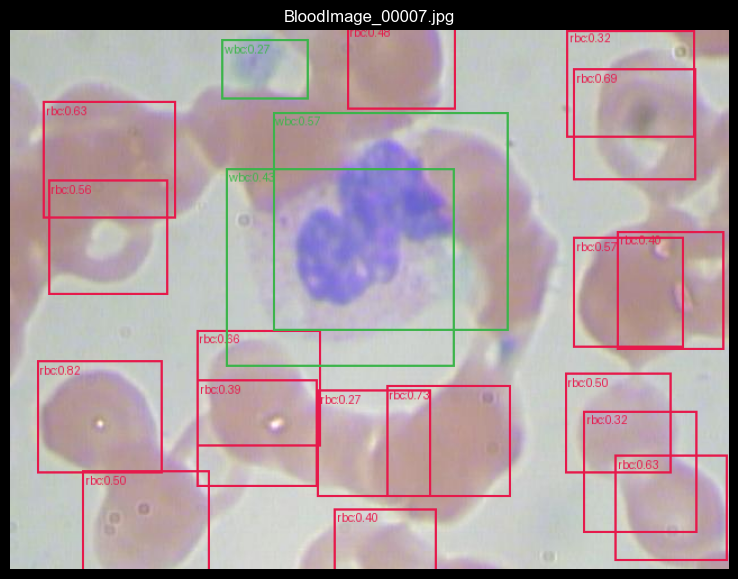

In [12]:
sample_image_path = Path(test_dataset.images[0])
orig_image = Image.open(sample_image_path).convert("RGB")

resize = torchvision.transforms.Resize((300, 300))
to_tensor = torchvision.transforms.ToTensor()
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]
normalize = torchvision.transforms.Normalize(mean=imagenet_mean, std=imagenet_std)

image = normalize(to_tensor(resize(orig_image))).to(device)

model.eval()
with torch.no_grad():
    predicted_locs, predicted_scores = model(image.unsqueeze(0))
    det_boxes_i, det_labels_i, det_scores_i = model.detect_objects(
        predicted_locs,
        predicted_scores,
        min_score=0.2,
        max_overlap=0.45,
        top_k=20,
    )

boxes = det_boxes_i[0].cpu()
labels = det_labels_i[0].cpu()
scores = det_scores_i[0].cpu()

orig_w, orig_h = orig_image.size
scale = torch.FloatTensor([orig_w, orig_h, orig_w, orig_h]).unsqueeze(0)
boxes = boxes * scale

annotated = orig_image.copy()
draw = ImageDraw.Draw(annotated)

for box, lbl, score in zip(boxes, labels, scores):
    cls_name = ssd_utils.rev_label_map[int(lbl)]
    if cls_name == "background":
        continue

    box = box.tolist()
    color = ssd_utils.label_color_map[cls_name]
    draw.rectangle(xy=box, outline=color, width=2)
    draw.text((box[0] + 2, box[1] + 2), f"{cls_name}:{float(score):.2f}", fill=color)

plt.figure(figsize=(10, 7))
plt.imshow(annotated)
plt.axis("off")
plt.title(sample_image_path.name)
plt.show()